# COLLEGE EVENT FEEDBACK ANALYSIS – INTERNSHIP PROJECT

***
A Comprehensive Analysis of College Event Feedback Data to Drive Improvements and Enhance Student Experience.
***

In [3]:
# importing important libraries and reading data file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('student_feedback.csv')
data.head()

,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9


In [4]:
# about data
data.describe()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   Unnamed: 0                                            1001 non-null   int64
 1   Student ID                                            1001 non-null   int64
 2   Well versed with the subject                          1001 non-null   int64
 3   Explains concepts in an understandable way            1001 non-null   int64
 4   Use of presentations                                  1001 non-null   int64
 5   Degree of difficulty of assignments                   1001 non-null   int64
 6   Solves doubts willingly                               1001 non-null   int64
 7   Structuring of the course                             1001 non-null   int64
 8   Provides support for students going above and beyond  1001 non-null   int64
 9

Unnamed: 0                                              0
Student ID                                              0
Well versed with the subject                            0
Explains concepts in an understandable way              0
Use of presentations                                    0
Degree of difficulty of assignments                     0
Solves doubts willingly                                 0
Structuring of the course                               0
Provides support for students going above and beyond    0
Course recommendation based on relevance                0
dtype: int64

In [5]:
# cleaning column names and drop index-like columns

# Replace spaces with underscores and lowercase column names
data.columns = [c.strip().replace(' ', '_').lower() for c in data.columns]

# Drop a stray index column often named 'unnamed: 0' if present
if 'unnamed:_0' in data.columns:
    data = data.drop(columns=['unnamed:_0'])
if 'unnamed:0' in data.columns:
    df = data.drop(columns=['unnamed:0'])

# Show final columns and first rows
print("Columns:", list(data.columns))
print("Shape after cleanup:", data.shape)
data.head()


Columns: ['student_id', 'well_versed_with_the_subject', 'explains_concepts_in_an_understandable_way', 'use_of_presentations', 'degree_of_difficulty_of_assignments', 'solves_doubts_willingly', 'structuring_of_the_course', 'provides_support_for_students_going_above_and_beyond', 'course_recommendation_based_on_relevance']
Shape after cleanup: (1001, 9)


,student_id,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9


In [6]:
# convert rating columns to numeric (coerce errors)
# We will assume 'student_id' is an identifier and not a rating.
cols = [c for c in data.columns if c != 'student_id']

for c in cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')

print("After conversion, missing values per column:")
print(data[cols].isnull().sum())

data.describe().T


After conversion, missing values per column:
well_versed_with_the_subject                            0
explains_concepts_in_an_understandable_way              0
use_of_presentations                                    0
degree_of_difficulty_of_assignments                     0
solves_doubts_willingly                                 0
structuring_of_the_course                               0
provides_support_for_students_going_above_and_beyond    0
course_recommendation_based_on_relevance                0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
student_id,1001.0,500.000000,289.108111,0.0,250.0,500.0,750.0,1000.0
well_versed_with_the_subject,1001.0,7.497502,1.692998,5.0,6.0,8.0,9.0,10.0
explains_concepts_in_an_understandable_way,1001.0,6.081918,2.597168,2.0,4.0,6.0,8.0,10.0
use_of_presentations,1001.0,5.942058,1.415853,4.0,5.0,6.0,7.0,8.0
degree_of_difficulty_of_assignments,1001.0,5.430569,2.869046,1.0,3.0,5.0,8.0,10.0
solves_doubts_willingly,1001.0,5.474525,2.874648,1.0,3.0,6.0,8.0,10.0
structuring_of_the_course,1001.0,5.636364,2.920212,1.0,3.0,6.0,8.0,10.0
provides_support_for_students_going_above_and_beyond,1001.0,5.662338,2.891690,1.0,3.0,6.0,8.0,10.0
course_recommendation_based_on_relevance,1001.0,5.598402,2.886617,1.0,3.0,6.0,8.0,10.0


In [7]:
# summary stats for all rating columns
cols = [c for c in data.columns if c != 'student_id']

print("Summary statistics (mean, std, min, max):")
display(data[cols].describe().T)


Summary statistics (mean, std, min, max):


,count,mean,std,min,25%,50%,75%,max
well_versed_with_the_subject,1001.0,7.497502,1.692998,5.0,6.0,8.0,9.0,10.0
explains_concepts_in_an_understandable_way,1001.0,6.081918,2.597168,2.0,4.0,6.0,8.0,10.0
use_of_presentations,1001.0,5.942058,1.415853,4.0,5.0,6.0,7.0,8.0
degree_of_difficulty_of_assignments,1001.0,5.430569,2.869046,1.0,3.0,5.0,8.0,10.0
solves_doubts_willingly,1001.0,5.474525,2.874648,1.0,3.0,6.0,8.0,10.0
structuring_of_the_course,1001.0,5.636364,2.920212,1.0,3.0,6.0,8.0,10.0
provides_support_for_students_going_above_and_beyond,1001.0,5.662338,2.891690,1.0,3.0,6.0,8.0,10.0
course_recommendation_based_on_relevance,1001.0,5.598402,2.886617,1.0,3.0,6.0,8.0,10.0


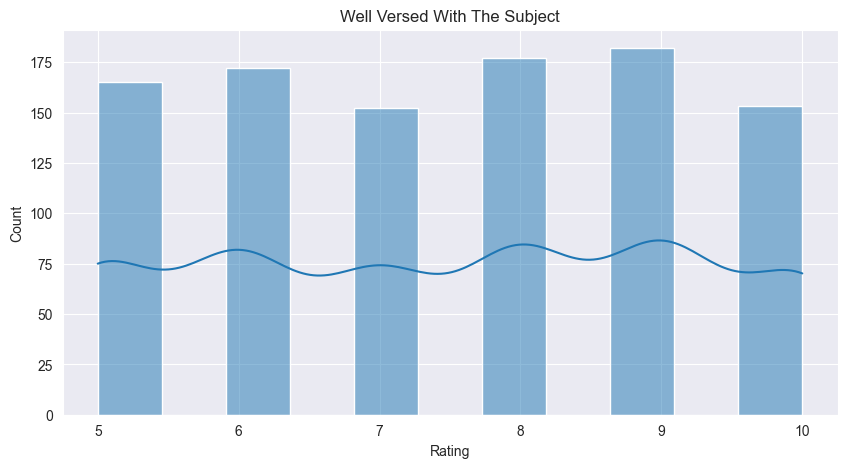

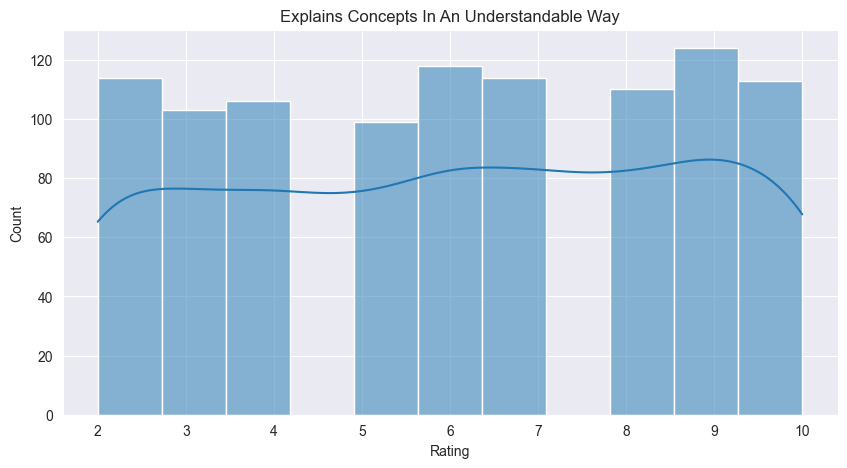

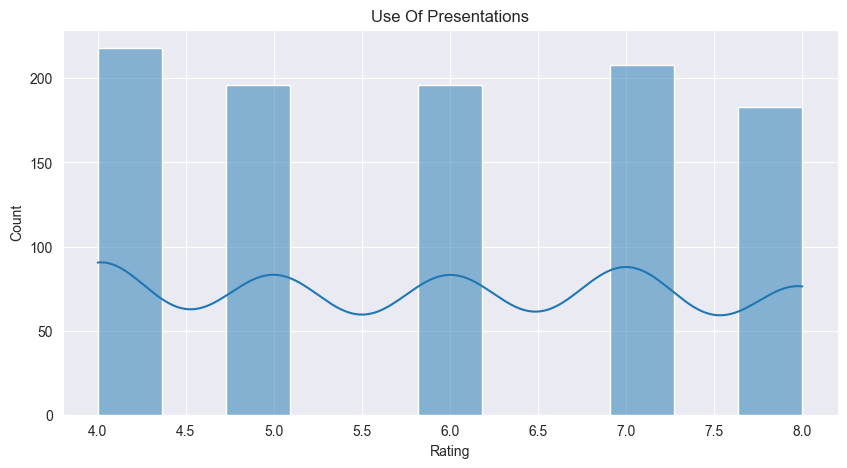

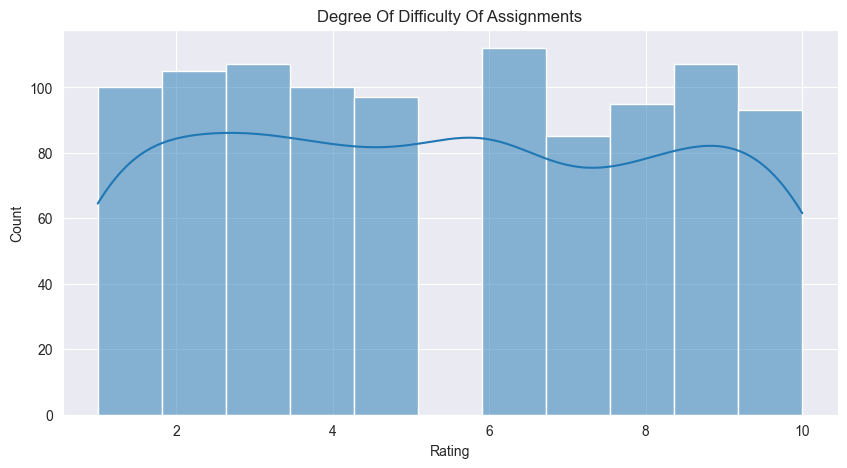

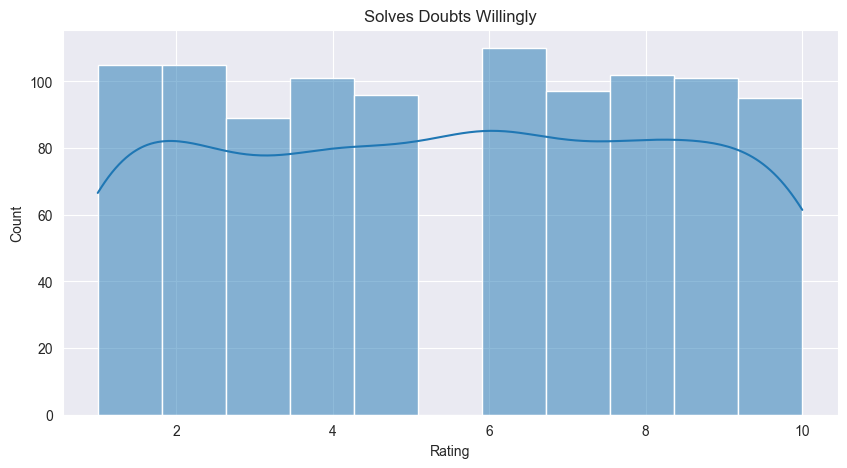

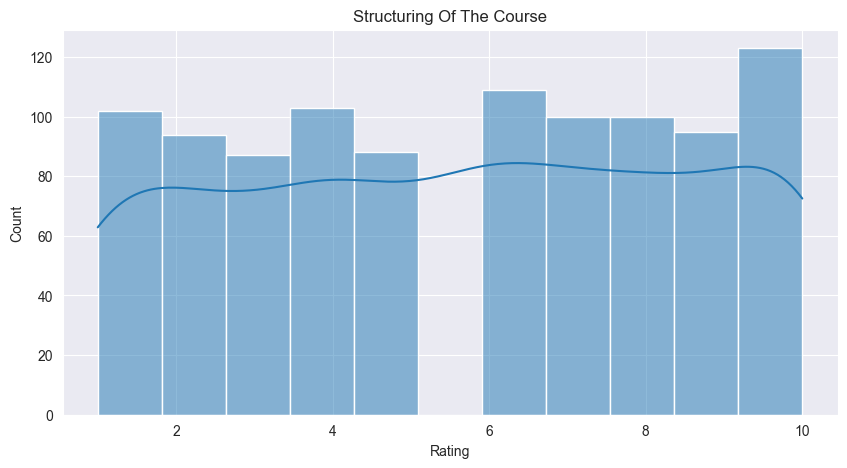

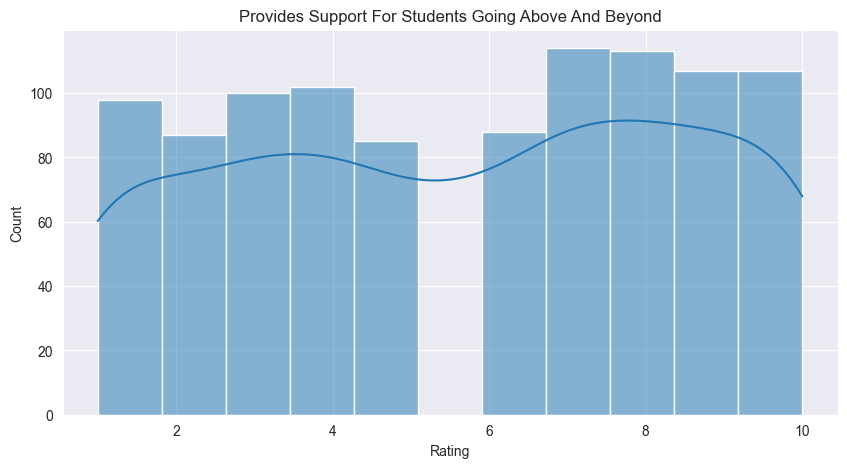

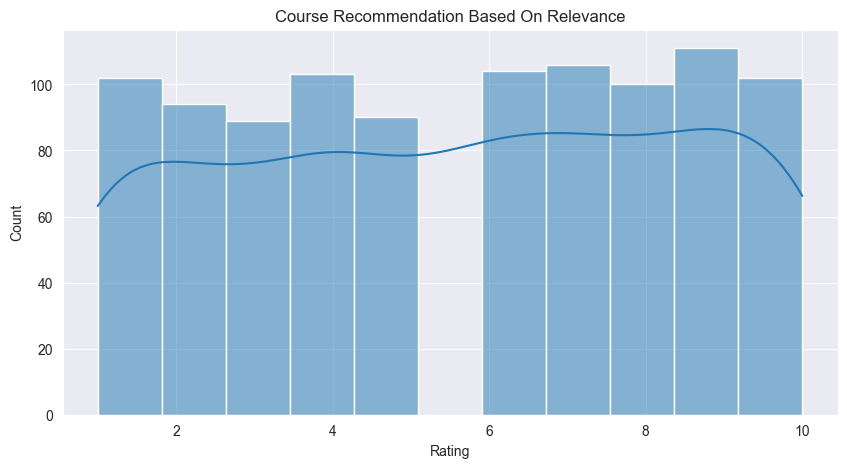

In [8]:
# Histograms for each rating column
# Exclude 'student_id' from histogram plotting
cols = [c for c in data.columns if c != 'student_id']

for c in cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[c].dropna(), kde=True)
    plt.title(c.replace('_', ' ').title())
    plt.xlabel("Rating")
    plt.show()


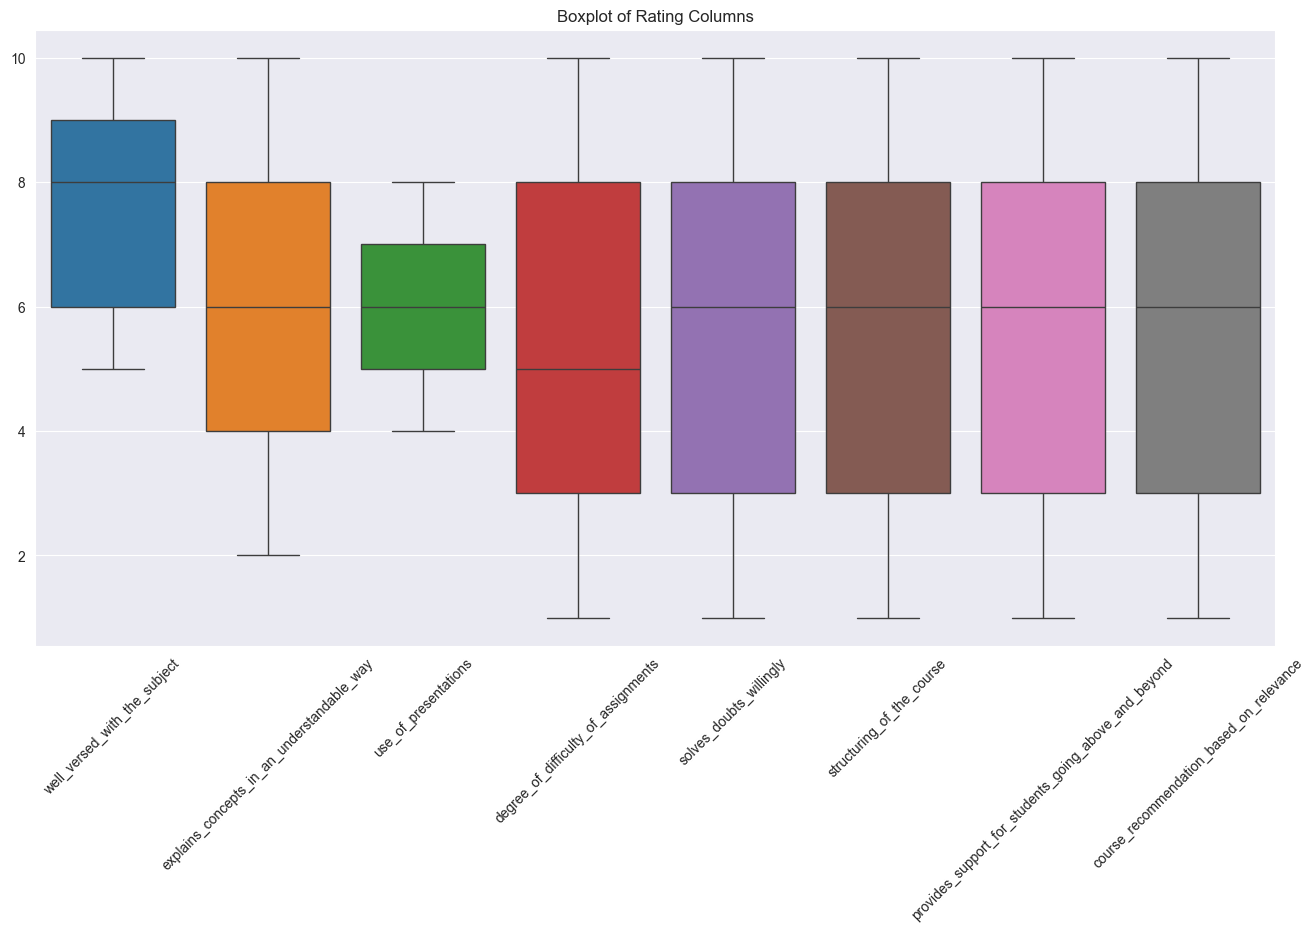

In [9]:
# Combined boxplot for comparison
plt.figure(figsize=(16, 8))
sns.boxplot(data=data[cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Rating Columns")
plt.show()


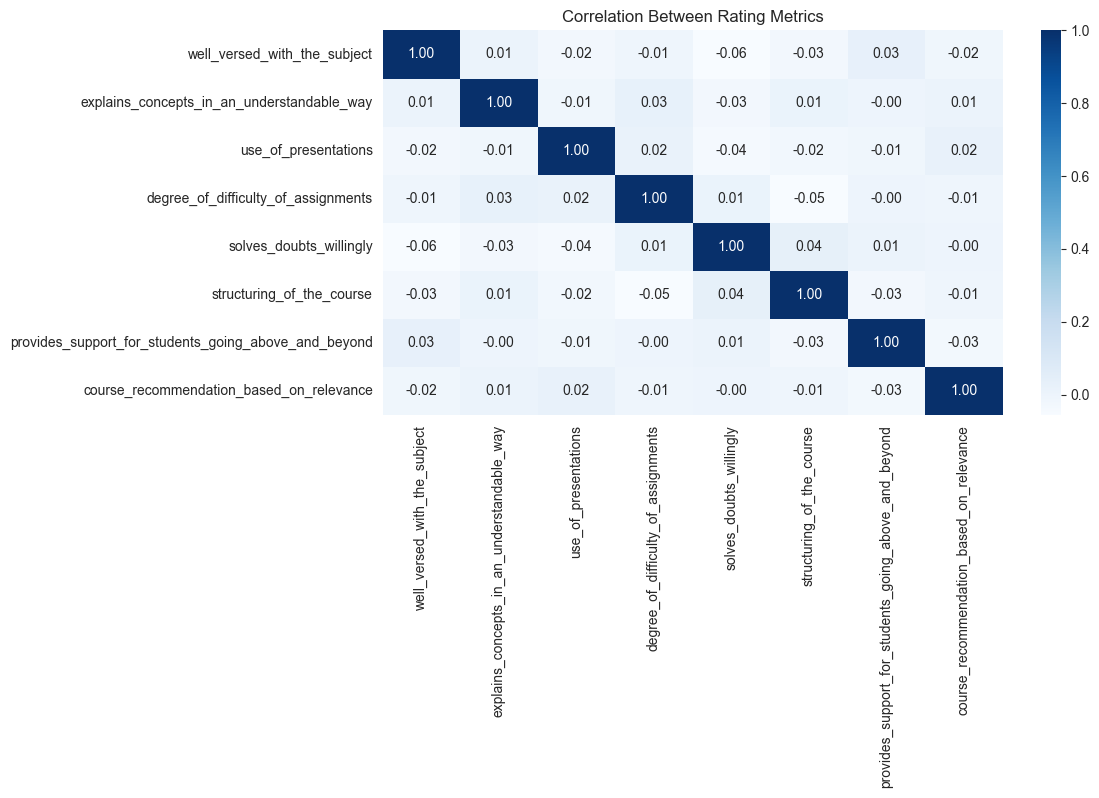

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 5))
corr = data[cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Between Rating Metrics")
plt.show()

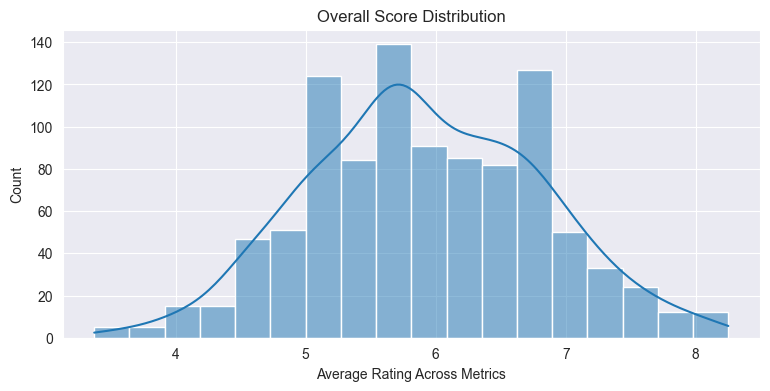

Top 5 students by overall score:


,student_id,overall_score,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance
199,770,8.250,10,10,5,7,10,7,7,10
110,188,8.250,7,6,8,9,9,8,9,10
692,238,8.250,8,7,5,10,10,9,7,10
580,78,8.125,10,9,6,8,10,7,7,8
658,269,8.125,9,10,6,10,10,1,9,10



Bottom 5 students by overall score:


,student_id,overall_score
644,281,3.375
592,54,3.375
743,724,3.500
612,73,3.625
285,450,3.625


In [11]:
# Overall score per student (mean of rating columns)
data['overall_score'] = data[cols].mean(axis=1)

plt.figure(figsize=(9, 4))
sns.histplot(data['overall_score'].dropna(), kde=True)
plt.title("Overall Score Distribution")
plt.xlabel("Average Rating Across Metrics")
plt.show()

# Show Top 5 and Bottom 5 overall scores
print("Top 5 students by overall score:")
display(
    data.sort_values('overall_score', ascending=False).head()[['student_id', 'overall_score'] + list(cols)]
)

print("\nBottom 5 students by overall score:")
display(
    data.sort_values('overall_score', ascending=True).head()[['student_id', 'overall_score']]
)


Mean rating by metric:


well_versed_with_the_subject                            7.497502
explains_concepts_in_an_understandable_way              6.081918
use_of_presentations                                    5.942058
provides_support_for_students_going_above_and_beyond    5.662338
structuring_of_the_course                               5.636364
course_recommendation_based_on_relevance                5.598402
solves_doubts_willingly                                 5.474525
degree_of_difficulty_of_assignments                     5.430569
dtype: float64

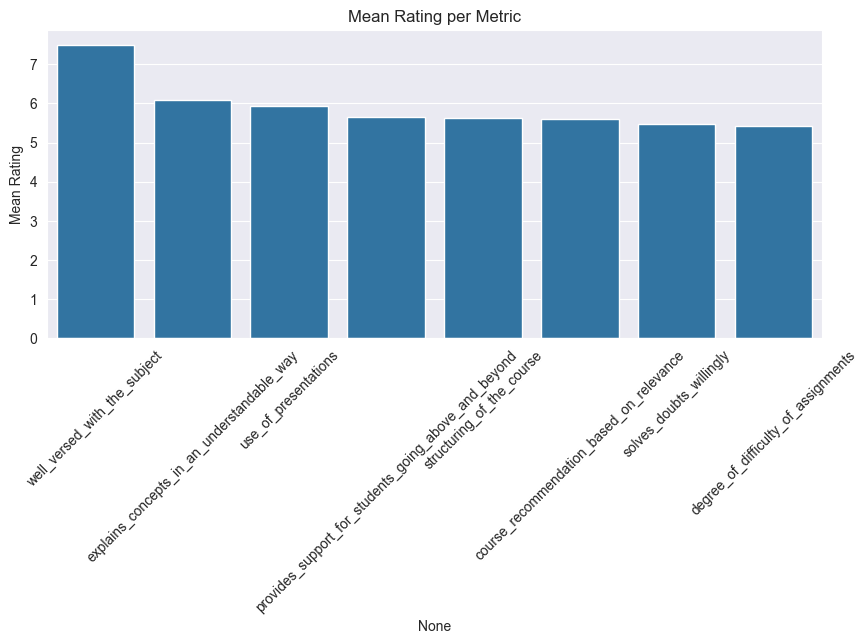

In [12]:
# Mean rating by metric
means = data[cols].mean().sort_values(ascending=False)

print("Mean rating by metric:")
display(means)

plt.figure(figsize=(10, 4))
sns.barplot(x=means.index, y=means.values)
plt.xticks(rotation=45)
plt.ylabel("Mean Rating")
plt.title("Mean Rating per Metric")
plt.show()


In [13]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

df = pd.read_csv('Student_Satisfaction_Survey.csv', encoding='ISO-8859-1')
df.head()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\gulshan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [14]:
# Clean column names
df.columns = df.columns.str.strip()

# Identify the comment column automatically
possible_cols = ['Total Feedback Given', 'Comments', 'Feedback', 'Remark', 'Review']
comment_col = None
for col in possible_cols:
    if col in df.columns:
        comment_col = col
        break

if comment_col is None:
    raise ValueError("⚠️ Comments/feedback column not found. Please tell me exact column name.")

print("✔ Using comment column:", comment_col)

# Sentiment label function
def get_sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply Sentiment Scoring
df['sentiment_score'] = df[comment_col].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_label'] = df['sentiment_score'].apply(get_sentiment_label)

print("✔ Sentiment columns successfully added!")

# Show sample output
display_cols = [col for col in df.columns if col in ['SN', comment_col, 'Course Name', 'Basic Course']]
df[display_cols + ['sentiment_score', 'sentiment_label']].head()


✔ Using comment column: Total Feedback Given
✔ Sentiment columns successfully added!


,SN,Total Feedback Given,Course Name,Basic Course,sentiment_score,sentiment_label
0,1,1,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,0.0,Neutral
1,2,1,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,0.0,Neutral
2,3,1,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,0.0,Neutral
3,4,1,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,0.0,Neutral
4,5,1,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY,0.0,Neutral


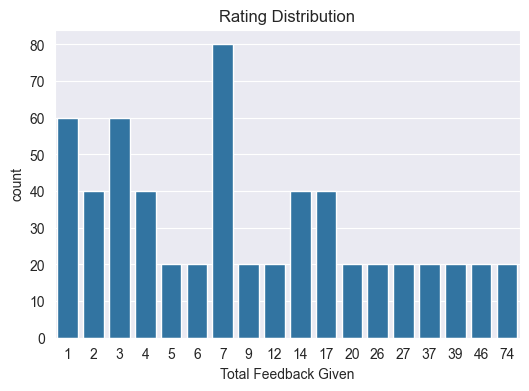

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Total Feedback Given', data=df)
plt.title("Rating Distribution")
plt.show()


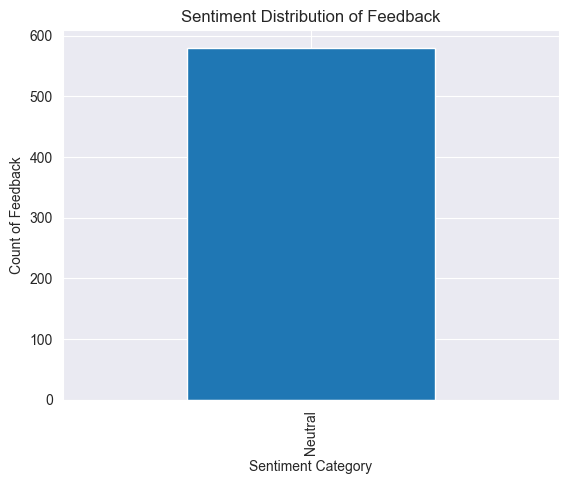

In [20]:

df['sentiment_label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution of Feedback")
plt.xlabel("Sentiment Category")
plt.ylabel("Count of Feedback")
plt.show()


# →                                Recommendations

1 Fix Food Quality: Review vendors, ensure variety, and enforce strict hygiene.

2 Enforce Strict Timing: Appoint a coordinator to eliminate delays and ensure timely schedules.

3 Boost Engagement: Make events more interactive (polls, Q&A) to increase attendance.

4 Improve Promotions: Use better outreach (social media/email) for maximum awareness.

5 Use Live Feedback: Implement quick, digital feedback (QR codes) for immediate data collection.


In [30]:
df.to_excel("Sentiment_Result.xlsx", index=False)
print("✔ File Saved: Sentiment_Result.xlsx")

✔ File Saved: Sentiment_Result.xlsx
